<a href="https://colab.research.google.com/github/cabreonictor/Ciencia-de-Datos-y-Optimizacion-de-Modelos/blob/main/notebook/Proyecto_Ciencia_de_Datos_y_Optimizaci%C3%B3n_de_Modelos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Proyecto Integrador Ciencia de Datos**

## Análisis exploratorio de datos sobre obesidad y factores de riesgo

**Integrantes:** Nancy Ferro - Angeles Deluca - Jimena Lasci - Lucio Mamani

##**Primera Entrega**

# **1. Objetivo y alcances**

El objetivo del presente trabajo es analizar un conjunto de datos relacionado con la salud y hábitos de la población, con el fin de identificar factores que influyen en el índice de masa corporal (IMC) y la presencia de obesidad.

Se busca comprender la relación entre variables como edad, sexo, actividad física y condiciones de salud (diabetes, hipertensión, entre otras) con la clasificación del IMC.

Este análisis permitirá obtener información relevante para la toma de decisiones y la posterior construcción de modelos predictivos.

# **2. Análisis exploratorio de datos**

## Preguntas guía para la exploración
1. ¿Cuáles serían mis variables de entrada y cuáles las de salida?  
2. ¿Es posible caracterizar la obesidad sólo mediante el índice de masa corporal, o se podría incluir más variables, como la medida de la cintura o alguna otra?  
3. ¿Hay alguna variable en el dataset que determine la proporción de grasa en el cuerpo?  
4. ¿Existen diferencias apreciables en la obesidad según características generales como la edad, el género o el nivel socioeconómico?  
5. ¿Se cumplen los supestos generalmente conocidos respecto a la actividad física, el sedentarismo, la calidad de la alimentación y la obesidad?  
6. ¿Está la obesidad fuertemenete relacionada con otras enfermedades?


In [ ]:
# CARGA DEL DATASET:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

URL = ('https://github.com/cabreonictor/Ciencia-de-Datos-y-Optimizacion-de-Modelos/raw/refs/heads/main/data/base%20para%20publicar%20obesidad%20C%C3%B3rdoba.xls')
df = pd.read_excel(URL)
df.head()

,n_encuesta,dia,mes,est,ecar,hta,HTA,dlp,ec,ic,...,Fef,Fer,Naf,Nar,Kf,Kr,acúrf,acúrr,Ncomr,id
0,1,6,11,4,2,2,2,1,1,1,...,12.37,7.58,1124.74,689.40,1908.62,1902.34,431.19,875.75,4.0,1
1,2,6,11,4,1,1,1,1,2,1,...,9.50,10.20,1576.12,928.59,1896.30,1834.77,530.22,753.23,5.0,2
2,3,6,11,4,2,1,1,1,1,1,...,9.62,10.38,1199.42,909.87,2310.79,2321.60,481.01,935.28,4.0,3
3,4,6,11,4,1,1,1,1,1,1,...,4.81,0.00,661.66,0.00,1829.69,0.00,295.65,0.00,0.0,4
4,5,7,11,4,1,1,1,1,1,1,...,10.09,0.00,1001.07,0.00,2061.93,0.00,539.30,0.00,0.0,5


## Variables relevantes

**Características físicas:**  
peso: var. cuantitativa en [kg]  
talla: var. cuantitativa en [m]  
IMC: (índice de masa corporal) var. cuantitativa en [kg/m^2]  
clasifIMC: (grado de obesidad) var. cualitativa  
cc: (circunferencia de cintura) var. cuantitativa en [cm]
  
**Alimentación:**  
Gcarhue: (carnes y huevos) var. cuantitativa en [gr/día]    
Ghort: (hortalizas) var. cuantitativa en [gr/día]  
Gcetu: (cereales y tubérculos) var. cuantitativa en [gr/día]  
Gceint: (cereales integrales) var. cuantitativa en [gr/día]  
Gazmil: (azúcar y miel) var. cuantitativa en [gr/día]  
  
**Hábitos:**  
fuma: var. cualitativa 1- no; 2- si  
actfis: (actividad física) var. cualitativa 1- no; 2- si  
durac: (duración de la actividad física) var. cuantitativa en [min]  
veces: (cantidad de veces por semana que realiza la actividad) var. cuantitativa  
senth: (tiempo que pasa el individuo sentado) var. cuantitativa en [hr]  

**Datos personales:**  
sexo: var. cualitativa 1-sexo masculino. 2- sexo femenino  
edad: var. cuantitativa en [años]  
eciv: (estado civil) var. cualitativa  
nhijos: (número de hijos) var. cuantitativa (sin hijos = 999)  

**Enfermedades:**  
ecar: (Presencia de enfermedad cardiovascular) var. cualitativa 1- no; 2- si.  
hta: (Presencia de hipertensión arterial) var. cualitativa 1- no; 2- si  
dlp: (Presencia de dislipemia) var. cualitativa 1- no; 2- si  
ec: (Presencia de enfermedad cardíaca) var. cualitativa 1- no; 2- si  
ic: (Presencia de insuficiencia cardíaca) var. cualitativa 1- no; 2- si  
ten1max: (máxima de tensión arterial) var. cuantitativa [mm Hg]  
ten1min: (mínima de tensión arterial) var. cuantitativa [mm Hg]  
dbt: (Presencia de diabetes) var. cualitativa 1- no; 2- si  
cancer: 1- no; 2- si.  

**Nivel socioeconómico:**  
eent: (educación del entrevistado) var. cualitativa   
nes: (nivel económico social) var. cualitativa   

El dataset posee además variables referidas al consumo de alimentos específicos.

## Análisis descriptivo
### Medidas de tendencia central, medidas de dispersión y correlaciones

In [ ]:
# INFO DEL DATASET:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4292 entries, 0 to 4291
Columns: 239 entries, n_encuesta to id
dtypes: float64(186), int64(45), object(8)
memory usage: 7.8+ MB


In [ ]:
# MEDIDAS DE TENDENCIA CENTRAL Y DE DISPERSIÓN:

df.describe()

,n_encuesta,dia,mes,est,ecar,hta,HTA,dlp,ec,ic,...,Fef,Fer,Naf,Nar,Kf,Kr,acúrf,acúrr,Ncomr,id
count,4292.000000,4292.000000,4292.000000,4292.000000,4292.000000,4292.000000,4292.000000,4292.000000,4292.000000,4292.000000,...,4292.000000,4292.000000,4.167000e+03,4292.000000,4273.000000,4292.000000,4273.000000,4292.000000,4254.000000,4292.000000
mean,2158.263979,3.493476,8.753495,3.050326,1.265377,1.188490,1.321761,1.092731,1.020736,1.016775,...,16.211445,3.160669,2.201504e+03,370.232789,3221.463014,515.903781,1420.732976,231.076130,0.830042,2146.500000
std,1241.728159,1.809039,3.122049,1.080012,0.441585,0.391149,0.467206,0.290088,0.142517,0.128444,...,46.253986,51.904748,2.286985e+04,998.655104,7795.825878,3468.338785,2328.264453,534.349807,1.718225,1239.138007
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,1086.750000,2.000000,7.000000,3.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,9.860000,0.000000,1.143050e+03,0.000000,2113.240000,0.000000,833.380000,0.000000,0.000000,1073.750000
50%,2159.500000,3.000000,9.000000,3.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,12.920000,0.000000,1.704820e+03,0.000000,2825.260000,0.000000,1236.780000,0.000000,0.000000,2146.500000
75%,3233.250000,5.000000,11.000000,4.000000,2.000000,1.000000,2.000000,1.000000,1.000000,1.000000,...,16.832500,0.000000,2.415035e+03,0.000000,3721.720000,0.000000,1744.040000,0.000000,0.000000,3219.250000
max,4306.000000,7.000000,12.000000,4.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,...,1756.000000,3344.850000,1.473039e+06,14776.300000,362610.000000,209075.000000,104467.000000,7401.780000,7.000000,4292.000000


In [ ]:
# CORRELACIONES (PEARSON):

df.corr(numeric_only=True)

,n_encuesta,dia,mes,est,ecar,hta,HTA,dlp,ec,ic,...,Fef,Fer,Naf,Nar,Kf,Kr,acúrf,acúrr,Ncomr,id
n_encuesta,1.000000,-0.040417,-0.334972,-0.137284,-0.026869,-0.031114,0.050371,-0.009679,-0.030932,-0.047528,...,0.024053,-0.013606,0.026534,0.085966,0.011153,-0.005753,-0.010345,-0.000409,-0.003709,0.999997
dia,-0.040417,1.000000,0.039905,0.040007,0.004064,0.013430,0.029644,-0.007285,-0.026141,-0.012567,...,-0.003524,-0.023631,0.012477,-0.034947,-0.000655,0.009504,0.023151,-0.013902,-0.009982,-0.040299
mes,-0.334972,0.039905,1.000000,0.600213,-0.013224,-0.014041,0.011731,-0.024417,-0.013650,0.027749,...,0.033209,0.016326,0.009829,-0.005708,-0.002924,0.015194,-0.069175,0.032376,0.032225,-0.334643
est,-0.137284,0.040007,0.600213,1.000000,-0.008464,-0.005910,0.033484,0.029732,-0.009810,0.027512,...,-0.079265,0.019930,-0.034559,0.023033,0.010734,0.028146,-0.060747,0.064248,0.089675,-0.136562
ecar,-0.026869,0.004064,-0.013224,-0.008464,1.000000,0.800509,0.595870,0.020703,-0.039321,0.020104,...,-0.002329,0.021265,-0.014909,-0.045739,0.027816,-0.017015,0.046004,-0.013257,-0.019753,-0.026970
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Kr,-0.005753,0.009504,0.015194,0.028146,-0.017015,-0.013522,-0.010302,-0.002627,-0.006274,-0.003753,...,-0.006875,0.046686,0.008930,0.197621,-0.003952,1.000000,-0.004808,0.270503,0.270739,-0.005814
acúrf,-0.010345,0.023151,-0.069175,-0.060747,0.046004,0.049846,0.048565,-0.004465,-0.007282,0.000182,...,0.021356,-0.001238,-0.003594,0.002926,0.015662,-0.004808,1.000000,0.037846,0.005044,-0.010505
acúrr,-0.000409,-0.013902,0.032376,0.064248,-0.013257,-0.016439,0.010699,0.009323,-0.023233,0.000955,...,-0.022127,0.126269,0.006507,0.540790,-0.010283,0.270503,0.037846,1.000000,0.759758,-0.000535
Ncomr,-0.003709,-0.009982,0.032225,0.089675,-0.019753,-0.018502,-0.002439,0.020506,-0.006571,0.004494,...,-0.023712,0.109547,-0.008613,0.572889,-0.009615,0.270739,0.005044,0.759758,1.000000,-0.003719


## Valores faltantes y atípicos

In [ ]:
# VALORES NULOS:

df.isnull().sum()

,0
n_encuesta,0
dia,0
mes,0
est,0
ecar,0
...,...
Kr,0
acúrf,19
acúrr,0
Ncomr,38


In [ ]:
# VALORES ATÍPICOS PARA LA VARIABLE IMC:
Q1 = df['IMC'].quantile(0.25)
Q3 = df['IMC'].quantile(0.75)
RIC = Q3 - Q1

limite_inferior = Q1 - 1.5 * RIC
limite_superior = Q3 + 1.5 * RIC

print('Q1:', Q1)
print('Q3:', Q3)
print('RIC:', RIC)
print('Limite inferior:', limite_inferior)
print('Limite superior:', limite_superior)

# Detectar los atípicos
outliers = df[(df['IMC'] < limite_inferior) | (df['IMC'] > limite_superior)]
print(outliers['IMC'])

Q1: 22.49134948096886
Q3: 28.383027337109578
RIC: 5.891677856140717
Limite inferior: 13.653832696757785
Limite superior: 37.22054412132066
0       39.393079
14      42.608566
39      38.904227
47      39.111111
147     41.401633
          ...    
3754    37.228502
3946    45.953361
3959    43.425926
4022    40.903686
4076    41.808390
Name: IMC, Length: 114, dtype: float64


Existe en este dataset una codificación usada para ciertos valores que deberían ser 0. Por ejemplo, para el caso de la variable 'cant', que representa la cantidad de cigarrillos que una persona fuma por semana, se usa el valor '999', para el caso de la persona que no fuma.  


Lo mismo ocurre para la variable 'tiempo', que representa la cantidad en años, de la presencia de la diabetes en la persona. Para una persona sin diabetes se codifica como '999'

También sucede con la variable 'nhijos', que representa la cantidad de hijos de la persona.

# **3. Visualización de datos**



## Gráficos de barra

La variable clasifIMC categoriza el grado de obesidad:  
1- menos de 18.5 kg / m2 : bajo peso  
2- de 18.5 a 24.9 kg / m2: peso normal  
3- de 25 a 29.9 kg / m2: preobesidad  
4- más de 30 a 34.9 kg / m2: Obesidad grado I  
5- 35 a 39.9 kg / m2: Obesidad grado II  
6- Mayor o igual a 40 kg / m2: Obesidad grado III  

Variable sexo: 1 - masculino, 2 - femenino

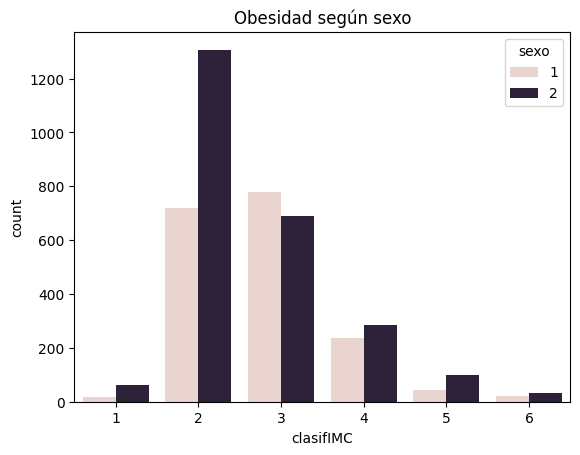

In [ ]:
sns.countplot(x='clasifIMC', hue='sexo', data=df)
plt.title("Obesidad según sexo")
plt.show()

Se puede observar que para ambos géneros, la cantidad de personas con obesidad es menor a la que no posee dicha condición, y que el mayor grado de obesidad, 6 - obesidad grado III, es bastante pequeño. Existe una diferencia en cambio, para los valores 2 - peso normal,  y 3 - preobesidad. En el caso de sexo femenino, la mayor frecuencia se ubica en la zona de preobesidad, en contraparte con el masculino, que se ubica en peso normal.

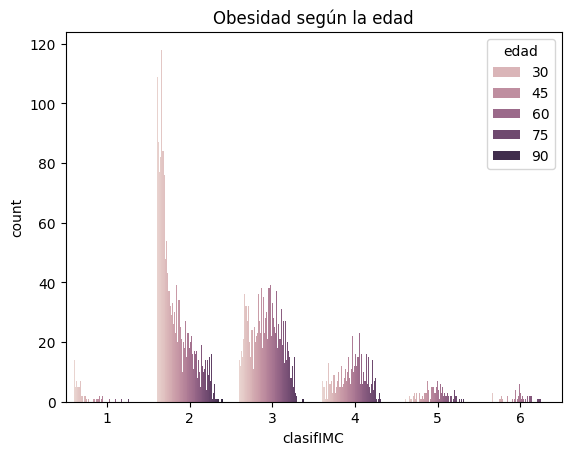

In [ ]:
sns.countplot(x='clasifIMC', hue='edad', data=df)
plt.title("Obesidad según la edad")
plt.show()

En cuanto a la edad, se puede observar que también es mayor la frecuencia para el peso normal, y que va disminuyendo según el grado de obesidad. Se puede observar, que la distribución de las edades cambia a partir de la preobesidad. Para valores casos de peso bajo y normales, la curva es asimétrica positiva, pero, a partir de la preobesidad es simétrica tipo normal.

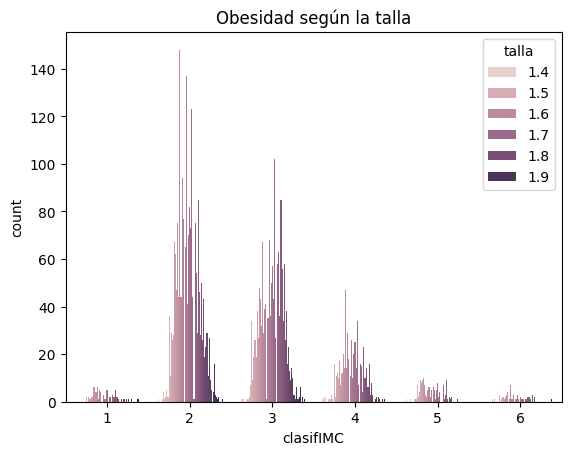

In [ ]:
sns.countplot(x='clasifIMC', hue='talla', data=df)
plt.title("Obesidad según la talla")
plt.show()

Para la obesidad según la talla, las distribuciones parecen ser más simétricas en general, y también se comportan de manea similar a las anteriores, donde la mayor frecuencia ocurre en peso normal. Se puede observar que las personas de baja y alta estatura suelen ser menos obesas que la de talla mediana.

## Histogramas

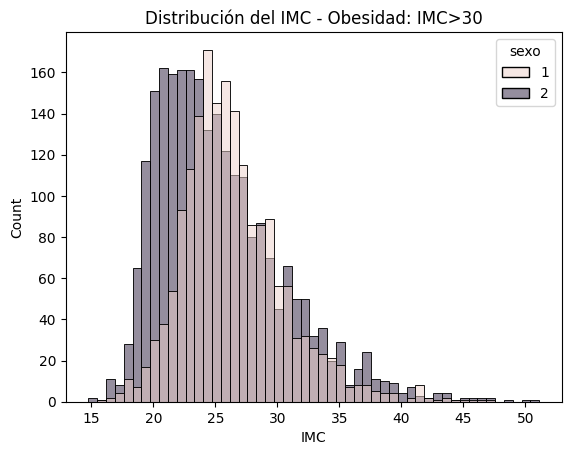

In [ ]:
sns.histplot(data=df, x='IMC', hue = 'sexo')
plt.title("Distribución del IMC - Obesidad: IMC>30")
plt.show()

El índice de masa corporal, IMC = peso/talla^2, es más frecuente en valores mayores en 1 - masculino que en 2 - femenino. La distribución para femenino es más asimétrica positiva, mientras que para masculino es más simétrica de tipo normal. Se puede ver que la obesidad ocurre más allá del valor medio de IMC.

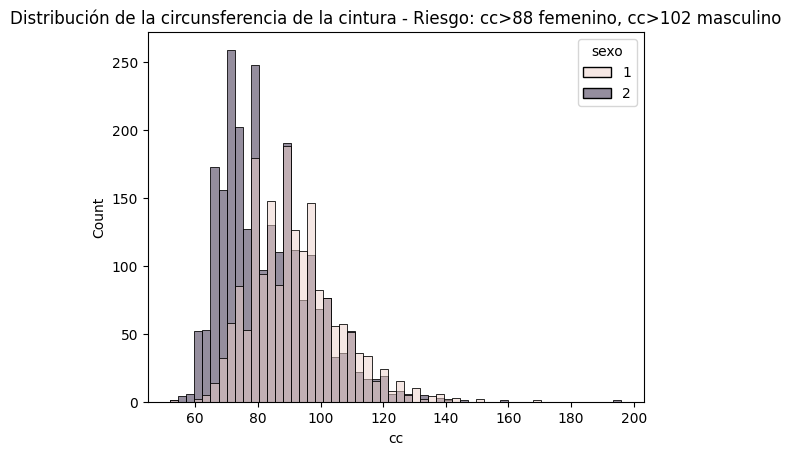

In [ ]:
sns.histplot(data=df, x='cc', hue = 'sexo')
plt.title("Distribución de la circunsferencia de la cintura - Riesgo: cc>88 femenino, cc>102 masculino")
plt.show()

Ocurre algo similar en el caso de la circunferencia de la cintura. La diferencia aparece en la altura de los valores los valores más frecuentes. El valor normal de la cintura en mujeres es menor que en varones, y además es más frecuentes.

## Diagramas de dispersión

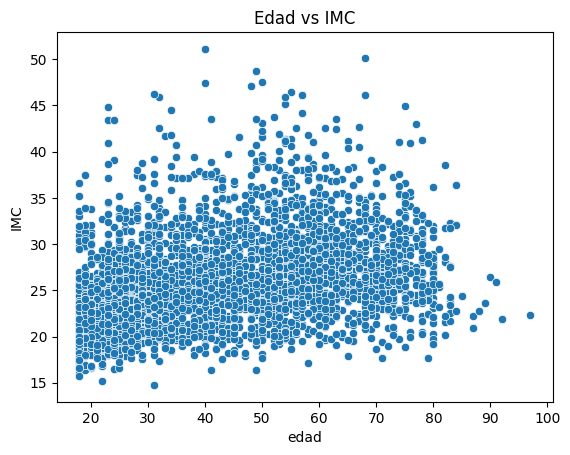

In [ ]:
sns.scatterplot(x='edad', y='IMC', data=df)
plt.title("Edad vs IMC")
plt.show()

Si graficamos el IMC en función de la edad, se puede ver que hay una ligera tendencia lineal, pero con gran dispersión de los datos, por lo que es un indicador que la edad es un factor que poco influye en la obesidad.

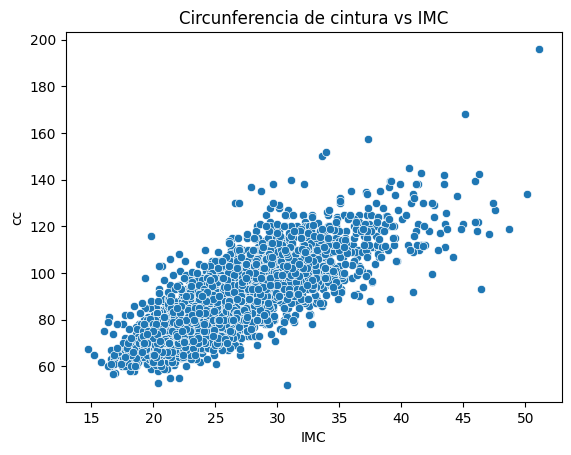

In [ ]:
sns.scatterplot(x='IMC', y='cc', data=df)
plt.title("Circunferencia de cintura vs IMC")
plt.show()

El valor de la circunferencia de la cintura vs. el IMC presenta un comportamiento más lineal y con menos dispersión, lo cual sea más representativo, ya que el IMC es proporcional al peso de las personas. es decir, a mayor peso, mayo es la cintura. La dispersión es considerable también.

## Boxplots

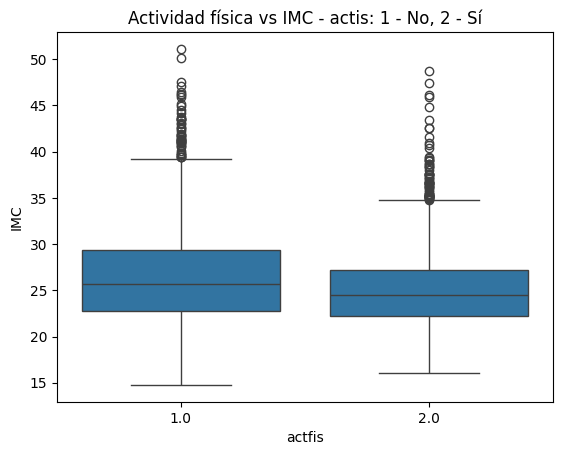

In [ ]:
sns.boxplot(x='actfis', y='IMC', data=df)
plt.title("Actividad física vs IMC - actis: 1 - No, 2 - Sí")
plt.show()

Se puede observar que el IMC medio es ligeramente mayor para las personas que no realizan actividad física con respecto a las que sí lo hacen. Es algo esperable, pero llamativamete la diferencia no es muy marcada. Esto puede ocurrir ya que el IMC se ve influenciado en gran medida por el tipo de alimentación, además de la actividad física. También se ve que es más disperso para las personas sedentarias, por lo que, para valores de IMC > 30 (obesidad), habrían más personas obesas en proporción a las que sí realizan actividad, cuya distribución es más compacta y los outliers ocurren para valores más bajos.

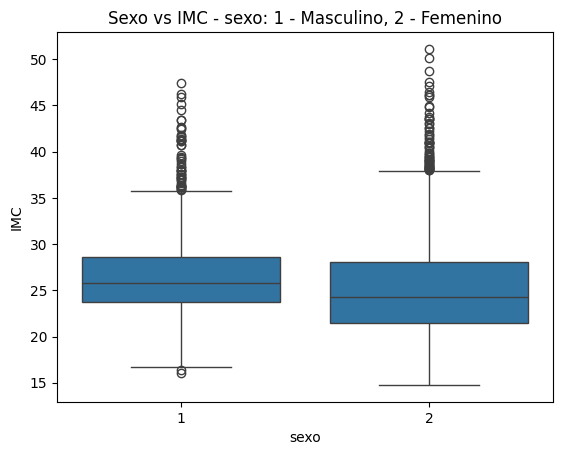

In [ ]:
sns.boxplot(x='sexo', y='IMC', data=df)
plt.title("Sexo vs IMC - sexo: 1 - Masculino, 2 - Femenino")
plt.show()

En cuanto al género, se puede ver que el IMC medio es menor en mujeres que en varones. Aquí la distribución es más dispersa en mujeres y los outliers ocurren a un valor mayor, por lo que habrían más mujeres obesas en proporción que varones.

# **4. Problemas de calidad de datos**

## Datos faltantes

Existen datos faltantes que se codifican con el valor '999'. Son datos que dependen de la respuesta anterior, como en el caso de la variable 'Nombre', que corresponde al nombre de la actividad física que realiza la persona, y que depende de la variable 'actfis', que indica si la persona realiza o no este tipo de actividad.

## Posibles outliers o extremos

Curiosamente, la obesidad de mayor grado se encuentra en la zona de los outliers, debido que en una poblacion, por lo general, el IMC de una persona sin obesidad tiende a ser normal y estar cerca de la media. Por lo que en este caso estos outliers son importantes.

## **5. Conclusiones**

El análisis exploratorio permitió identificar relaciones entre variables como la edad, el sexo, la actividad física y el IMC y la circunferencia de cintura.

Se observó que la actividad física podría actuar como un factor protector frente a la obesidad, mientras que la edad presenta cierta influencia en el aumento del IMC, ya que la obesidad existe en todo el rango etario.


Se pudo observar también que existen ligeras diferencias entre el comportamiento del varón y de la mujer respecto a la obesidad.

Se econtraron algunas linealidades en los datos que podrían servir para la construcción de modelos, aunque es necesario excavar más en el dataset para mejorar la correlación.



##**Segunda Entrega**

##**1. Objetivos y alcances**

#**Objetivo General:**
Desarrollar e implementar modelos predictivos basados en aprendizaje automático supervisado para la detección temprana y clasificación del grado de obesidad en la población. Con ello se busca automatizar la identificación de perfiles de riesgo mediante variables clínicas, demográficas y de hábitos de vida.

#**Tipo de Problema:**
El presente desarrollo aborda el problema desde un enfoque de clasificación. La variable objetivo es clasifIMC, la cual categoriza de forma cualitativa el estado del peso corporal de la persona, al dividir el índice de masa corporal, en 6 categorías a saber: bajo peso, peso normal, obesidad grado I, obesidad grado II y obesidad grado III.


##**2. Análisis exploratorio de datos**
###**Análisis univariado de variables predictoras**

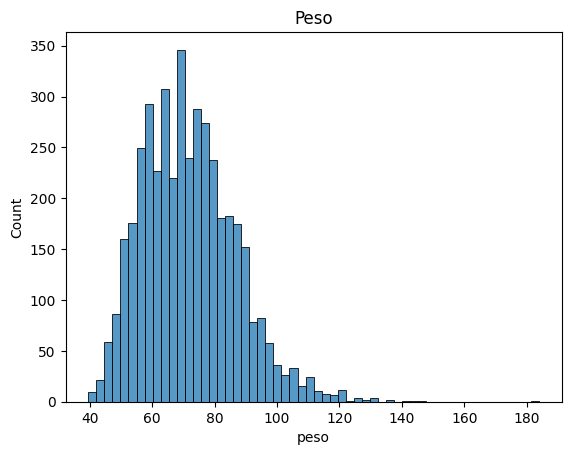

In [ ]:
sns.histplot(data=df, x='peso')
plt.title("Peso")
plt.show()

In [ ]:
print('Edad mínima:',df['edad'].min())
print('Peso medio:', df['peso'].mean().round(2), 'kg')

Edad mínima: 18
Peso medio: 71.92 kg


Una de las variables más evidentes para categorizar la obesidad es el peso. Como se observa, tiene una distribución asimétrica positiva. Esto es así porque en el dataset no se incluyen niños, que son las personas que poseen los pesos de menor valor. Además que, la obesidad, las personas pueden alcanzar varias veces el peso normal.

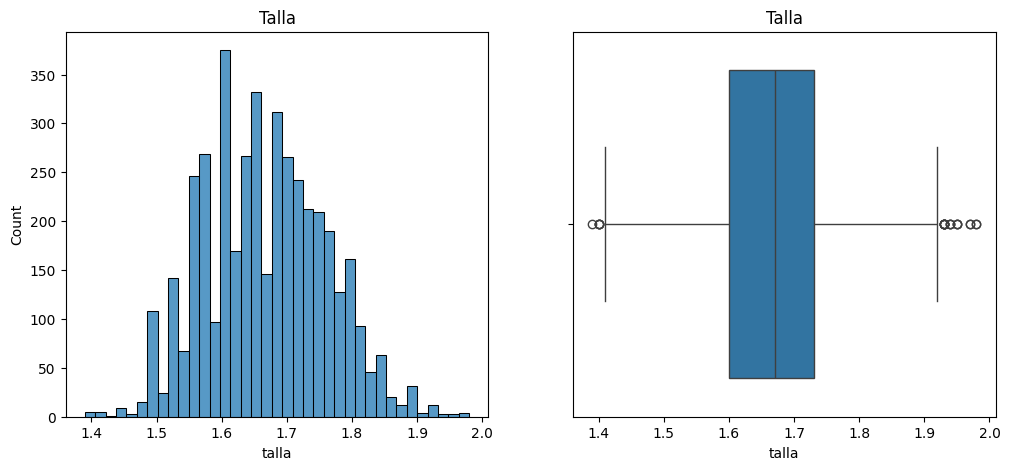

In [ ]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))
sns.histplot(data=df, x='talla', ax = axes[0])
axes[0].set_title("Talla")
sns.boxplot(data=df, x='talla', ax = axes[1])
axes[1].set_title("Talla")
plt.show()

In [ ]:
print('Talla media:',df['talla'].mean().round(2))
print('Talla mínima:',df['talla'].min())
print('Talla máxima:',df['talla'].max())


Talla media: 1.67
Talla mínima: 1.39
Talla máxima: 1.98


La talla es una variable bastante simétrica, con un valor medio de 1.67 m. Y presenta muy pocos outliers. Como la obesidad se caracteriza por el IMC, las personas de mayor altura pueden contener un peso mayor, sin verse afectado su estado corporal.

---





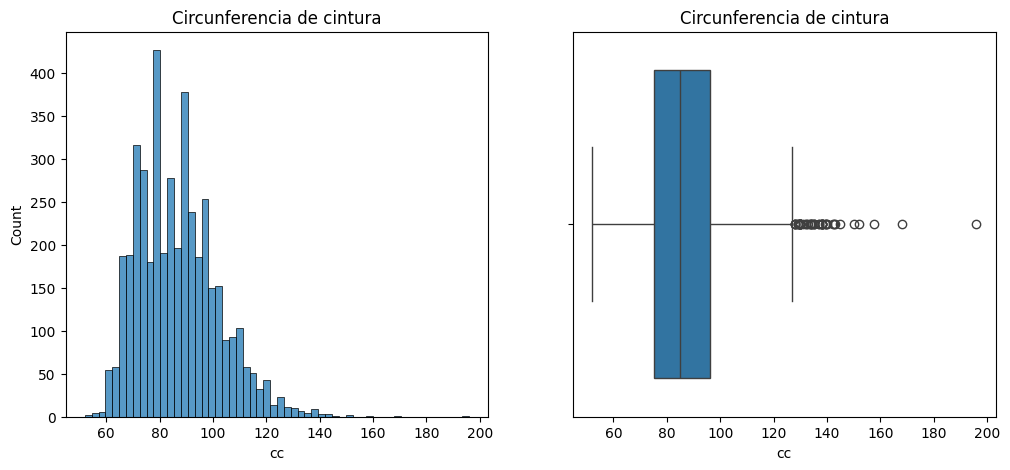

In [ ]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))
sns.histplot(data=df, x='cc', ax = axes[0])
axes[0].set_title("Circunferencia de cintura")
sns.boxplot(data=df, x='cc', ax = axes[1])
axes[1].set_title("Circunferencia de cintura")
plt.show()

La circunferencia de la cintura presenta una distribución ligeramente asimétrica positiva, y muchos outliers de mayor valor, que no deben ser descartados, ya que por lo general, la obesidad se asocia fuertemente un mayor valor de la cintura del cuerpo.

###**Análisis bivariado entre variable objetivo y las variables predictoras**

In [67]:
# Limpieza de variables:
# Cantidad de hijos: nhijos
df['nhijos'] = df['nhijos'].replace(999, 0)

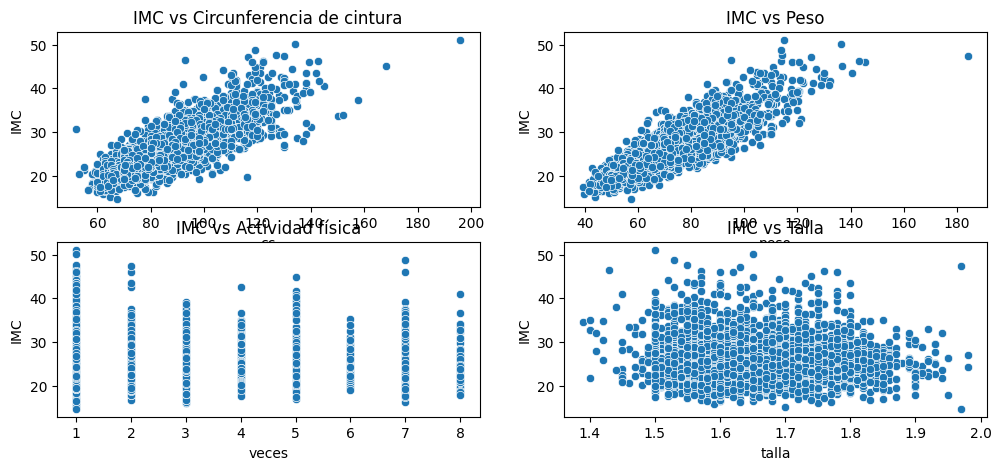

In [73]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 5))
sns.scatterplot(data=df, x='cc', y='IMC', ax = axes[0][0])
axes[0][0].set_title("IMC vs Circunferencia de cintura")
sns.scatterplot(data=df, x='peso', y='IMC', ax = axes[0][1])
axes[0][1].set_title("IMC vs Peso")
sns.scatterplot(data=df, x='veces', y='IMC', ax = axes[1][0])
axes[1][0].set_title("IMC vs Actividad física")
sns.scatterplot(data=df, x='talla', y='IMC', ax = axes[1][1])
axes[1][1].set_title("IMC vs Talla")

plt.show()

Como se puede ver, hay dos correlaciones fuertes del IMC con el peso y con la circunferencia de la cintura. No es el caso de la talla, que no repercute en el índice de masa corporal, ni tampoco la cantidad de veces que realiza actividade física por semana.

###**Posibles relaciones entre variables**
Para clasificar la obesidad se puede usar la variable clasifIMC, que surge a partir de la segmentación del IMC en diferentes rangos, por lo que una relación en IMC se corresponde con relación en clasifIMC. En este caso se observa que la variable peso y circunferencia de cintura presentan relaciones con la obesidad.


###**Valores faltantes, outliers y transformaciones**
La variable 'senth' que representa cantidad de horas sentadas de la persona por día, tiene valores incoherentes, repetidos y sin formato correspondiente, por lo que se descarta totalmente.
Los valores outliers de circunferencia de cintura y de peso son sumamente relevanes, ya que se corresponden con los grados elevados de obesidad y no pueden ser descartados, porque es información valiosa para el modelo.
La variable IMC se transforma mediante una segmentación de forma ordinal, en clasifIMC, que caracteriza los disntintos grados de obesidad.